###利用完整的长表master2，训练模型

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# 医药生物行业信用风险模型 —— 方案：纯ST事件预测
# Y = 未来3年内首次被ST
#
# 依赖：pandas, numpy, scipy, scikit-learn, xgboost, lightgbm, matplotlib
# 运行：python credit_risk_ST_prediction.py


import pandas as pd
import numpy as np
from scipy.stats import mstats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')


In [3]:
# ---------- 0. 路径配置 ----------
MASTER_PATH = '/content/drive/MyDrive/credit_risk_project/master2.csv'    # ← 财务+NLP宽表
BDT_PATH    = '/content/drive/MyDrive/credit_risk_project/BDT_CO.csv'    # ← ST事件数据

# ---------- 1. 读取数据 ----------
master = pd.read_csv(MASTER_PATH, dtype={'股票代码': str})
bdt    = pd.read_csv(BDT_PATH,    dtype={'Symbol': str})

master['报告期'] = pd.to_datetime(master['报告期'])
master['年份']   = master['报告期'].dt.year
master = master.sort_values(['股票代码', '报告期']).reset_index(drop=True)

print(f"master2: {len(master)} 行，{master['股票代码'].nunique()} 家公司")
print(f"BDT_CO : {len(bdt)} 行，ST公司 {bdt['FirstSTDate'].notna().sum()} 家")

# ---------- 2. 拼接 ST 事件 ----------
bdt_st = (bdt[bdt['FirstSTDate'].notna()]
          [['Symbol', 'FirstSTDate', 'FirstSTReason']]
          .copy())
bdt_st.columns = ['股票代码', 'FirstSTDate', 'FirstSTReason']
bdt_st['FirstSTDate'] = pd.to_datetime(bdt_st['FirstSTDate'])

df = master.merge(bdt_st, on='股票代码', how='left')

# 排除已经发生ST的年份及之后（防止信息泄露）
df = df[~(
    (df['FirstSTDate'].notna()) &
    (df['报告期'] >= df['FirstSTDate'])
)].copy()

print(f"\n排除ST后样本: {len(df)} 行")
print(f"ST原因分布（BDT_CO）:\n{bdt['FirstSTReason'].value_counts().to_string()}")


master2: 2333 行，451 家公司
BDT_CO : 519 行，ST公司 72 家

排除ST后样本: 2168 行
ST原因分布（BDT_CO）:
FirstSTReason
两年亏损             28
审计否定             19
信息披露违规            6
经营受损              4
两年亏损,资产缩水         3
资产缩水              3
资产缩水,两年亏损（调整）     1
两年亏损（调整）          1
重大诉讼              1
经营停顿              1
资产缩水,经营受损         1
财务破产              1
权益缩水              1
两年亏损,经营停顿         1
资产缩水,审计否定         1


In [4]:
# ---------- 3. 构造 Y ----------
# Y = 1：该年报告期结束后3年内，公司首次被ST
# Y = 0：该年报告期后3年内未发生ST（或公司从未被ST）
df['Y'] = (
    (df['FirstSTDate'].notna()) &
    (df['FirstSTDate'] > df['报告期']) &
    (df['FirstSTDate'] <= df['报告期'] + pd.DateOffset(years=3))
).astype(int)

print(f"\nY=1（将ST）: {df['Y'].sum()} 条，占比 {df['Y'].mean():.4f}")
print(f"各年份正样本:\n{df.groupby('年份')['Y'].agg(['sum','count','mean']).round(3).to_string()}")

# ---------- 4. 特征工程 ----------

# 4a. 对数变换（处理量纲差异）
for col in ['营业总收入', '营业利润', '净利润', '资产-总资产', '股东权益合计']:
    df[f'log_{col}'] = np.sign(df[col]) * np.log1p(np.abs(df[col]))

# 4b. 比率特征
df['ROE']        = df['净利润'] / df['股东权益合计'].replace(0, np.nan)
df['现金比率']    = df['资产-货币资金'] / df['资产-总资产'].replace(0, np.nan)
df['经营现金流比'] = df['经营性现金流-现金流量净额'] / df['资产-总资产'].replace(0, np.nan)
df['净利润率']    = df['净利润'] / df['营业总收入'].replace(0, np.nan)
df['营业利润率']  = df['营业利润'] / df['营业总收入'].replace(0, np.nan)
df['毛现金流质量'] = df['经营性现金流-现金流量净额'] / df['净利润'].replace(0, np.nan)

# 4c. 同比增长率
for col in ['净利润', '营业总收入', '营业利润', '资产-总资产']:
    df[f'{col}_增长率'] = df.groupby('股票代码')[col].pct_change()

# 4d. 滞后一期（趋势）
# 不放入任何亏损二值标记，避免间接泄露Y定义
for col in ['营业利润率', 'ROE', '经营现金流比', '净利润率', 'log_净利润']:
    df[f'{col}_lag1'] = df.groupby('股票代码')[col].shift(1)

# 4e. NLP 特征变换
df['log_risk_word_ratio']   = np.log1p(df['risk_word_ratio'])
df['log_uncertainty_ratio'] = np.log1p(df['uncertainty_ratio'])
df['log_mda_length']        = np.log1p(df['mda_length'])

# ---------- 5. 特征列表 ----------
FIN_FEATURES = [
    'log_营业总收入', 'log_资产-总资产', 'log_净利润',
    'ROE', '净利润率', '营业利润率',
    '现金比率', '经营现金流比', '毛现金流质量', '资产负债率',
    '净利润_增长率', '营业总收入_增长率', '营业利润_增长率', '资产-总资产_增长率',
    '营业利润率_lag1', 'ROE_lag1', '经营现金流比_lag1', '净利润率_lag1', 'log_净利润_lag1',
]
NLP_FEATURES = [
    'negative_score', 'negative_score_max',
    'log_risk_word_ratio', 'log_uncertainty_ratio', 'log_mda_length'
]
ALL_FEATURES = FIN_FEATURES + NLP_FEATURES


Y=1（将ST）: 16 条，占比 0.0074
各年份正样本:
      sum  count   mean
年份                     
2020    3    267  0.011
2021    4    339  0.012
2022    3    376  0.008
2023    3    390  0.008
2024    2    399  0.005
2025    1    397  0.003


In [5]:
# ---------- 6. 数据清洗 ----------
df_model = df.copy()
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)

# 用全局中位数填充（含 lag 特征的首年缺失）
global_med = df_model[ALL_FEATURES].median()
df_model[ALL_FEATURES] = df_model[ALL_FEATURES].fillna(global_med)

# Winsorize 5%–95%
WINSOR_COLS = [
    'ROE', '净利润_增长率', '营业总收入_增长率', '营业利润_增长率', '净利润率',
    '营业利润率', '经营现金流比', '毛现金流质量', '资产-总资产_增长率',
    '营业利润率_lag1', 'ROE_lag1', '经营现金流比_lag1', '净利润率_lag1'
]
for col in WINSOR_COLS:
    df_model[col] = mstats.winsorize(df_model[col], limits=[0.05, 0.05])

In [7]:
# ---------- 7. 时序交叉验证 ----------
FOLDS = [
    ([2020],                    2021, 'Fold1'),
    ([2020, 2021],              2022, 'Fold2'),
    ([2020, 2021, 2022],        2023, 'Fold3'),
    ([2020, 2021, 2022, 2023],  2024, 'Fold4'),
]

def train_fold(X_tr, y_tr, X_va, y_va):
    """训练三个模型并返回各自概率预测"""
    scale = max((y_tr == 0).sum() / max(y_tr.sum(), 1), 1)

    # Logistic Regression（balanced权重）
    sc = StandardScaler()
    lr = LogisticRegression(max_iter=1000, C=0.1, class_weight='balanced')
    lr.fit(sc.fit_transform(X_tr), y_tr)
    p_lr = lr.predict_proba(sc.transform(X_va))[:, 1]

    # XGBoost（scale_pos_weight处理不平衡）
    xgb = XGBClassifier(
        n_estimators=300, max_depth=3, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.7, min_child_weight=3,
        scale_pos_weight=scale, eval_metric='logloss',
        random_state=42, verbosity=0
    )
    xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    p_xgb = xgb.predict_proba(X_va)[:, 1]

    # LightGBM（early stopping防过拟合）
    lgbm = lgb.LGBMClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.7, min_child_samples=5,
        scale_pos_weight=scale, random_state=42, verbose=-1,
        importance_type='gain'
    )
    lgbm.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(30, verbose=False)]
    )
    p_lgbm = lgbm.predict_proba(X_va)[:, 1]

    return p_lr, p_xgb, p_lgbm, lgbm

records    = []
lgbm_final = None

for train_years, val_year, fold_name in FOLDS:
    tr = df_model[df_model['年份'].isin(train_years)]
    va = df_model[df_model['年份'] == val_year]
    X_tr, y_tr = tr[ALL_FEATURES], tr['Y']
    X_va, y_va = va[ALL_FEATURES], va['Y']

    n_pos_tr = int(y_tr.sum())
    n_pos_va = int(y_va.sum())

    if n_pos_va == 0:
        print(f"\n{fold_name} 验证{val_year}：无正样本，跳过")
        continue

    p_lr, p_xgb, p_lgbm, lgbm_obj = train_fold(X_tr, y_tr, X_va, y_va)
    p_ens = (p_lr + p_xgb + p_lgbm) / 3

    if val_year == 2024:
        lgbm_final = lgbm_obj

    row = {
        'Fold': fold_name, '验证年份': val_year,
        '训练正': n_pos_tr, '验证正': n_pos_va, '验证总': len(y_va),
        'LR_ROC':   roc_auc_score(y_va, p_lr),   'LR_PR':   average_precision_score(y_va, p_lr),
        'XGB_ROC':  roc_auc_score(y_va, p_xgb),  'XGB_PR':  average_precision_score(y_va, p_xgb),
        'LGBM_ROC': roc_auc_score(y_va, p_lgbm), 'LGBM_PR': average_precision_score(y_va, p_lgbm),
        'ENS_ROC':  roc_auc_score(y_va, p_ens),  'ENS_PR':  average_precision_score(y_va, p_ens),
    }
    records.append(row)

    print(f"\n{fold_name}  训练{train_years} → 验证{val_year}"
          f"  [训练正{n_pos_tr} / 验证正{n_pos_va}/{len(y_va)}]")
    print(f"  LR:   ROC={row['LR_ROC']:.3f}  PR-AUC={row['LR_PR']:.3f}")
    print(f"  XGB:  ROC={row['XGB_ROC']:.3f}  PR-AUC={row['XGB_PR']:.3f}")
    print(f"  LGBM: ROC={row['LGBM_ROC']:.3f}  PR-AUC={row['LGBM_PR']:.3f}")
    print(f"  集成: ROC={row['ENS_ROC']:.3f}  PR-AUC={row['ENS_PR']:.3f}")

res_df = pd.DataFrame(records)
print(f"\n{'='*65}")
print("均值（跨所有有效Fold）:")
for m in ['LR', 'XGB', 'LGBM', 'ENS']:
    print(f"  {m:5s}: ROC={res_df[f'{m}_ROC'].mean():.3f}  PR={res_df[f'{m}_PR'].mean():.3f}")



Fold1  训练[2020] → 验证2021  [训练正3 / 验证正4/339]
  LR:   ROC=0.350  PR-AUC=0.011
  XGB:  ROC=0.764  PR-AUC=0.208
  LGBM: ROC=0.852  PR-AUC=0.172
  集成: ROC=0.578  PR-AUC=0.016

Fold2  训练[2020, 2021] → 验证2022  [训练正7 / 验证正3/376]
  LR:   ROC=0.277  PR-AUC=0.007
  XGB:  ROC=0.939  PR-AUC=0.133
  LGBM: ROC=0.835  PR-AUC=0.024
  集成: ROC=0.599  PR-AUC=0.013

Fold3  训练[2020, 2021, 2022] → 验证2023  [训练正10 / 验证正3/390]
  LR:   ROC=0.811  PR-AUC=0.067
  XGB:  ROC=0.926  PR-AUC=0.087
  LGBM: ROC=0.620  PR-AUC=0.015
  集成: ROC=0.888  PR-AUC=0.055

Fold4  训练[2020, 2021, 2022, 2023] → 验证2024  [训练正13 / 验证正2/399]
  LR:   ROC=0.815  PR-AUC=0.021
  XGB:  ROC=0.892  PR-AUC=0.055
  LGBM: ROC=0.696  PR-AUC=0.014
  集成: ROC=0.849  PR-AUC=0.064

均值（跨所有有效Fold）:
  LR   : ROC=0.563  PR=0.026
  XGB  : ROC=0.880  PR=0.121
  LGBM : ROC=0.751  PR=0.056
  ENS  : ROC=0.728  PR=0.037


In [8]:
# ---------- 8. 特征重要性（Fold4 LightGBM）----------
fi = (pd.DataFrame({'feature': ALL_FEATURES,
                    'importance': lgbm_final.feature_importances_})
       .sort_values('importance', ascending=False)
       .reset_index(drop=True))
fi['type'] = fi['feature'].apply(lambda x: 'NLP' if x in NLP_FEATURES else '财务')

print(f"\n特征重要性 Top15（Fold4 LightGBM）:")
print(fi.head(15).to_string(index=False))



特征重要性 Top15（Fold4 LightGBM）:
              feature   importance type
                资产负债率 2.216170e+04   财务
log_uncertainty_ratio 1.147280e+04  NLP
               经营现金流比 1.102910e+04   财务
                 净利润率 7.073270e+03   财务
       negative_score 3.844270e+03  NLP
         log_净利润_lag1 2.365180e+03   财务
           log_资产-总资产 1.443289e-15   财务
            log_营业总收入 0.000000e+00   财务
                 现金比率 0.000000e+00   财务
                营业利润率 0.000000e+00   财务
              log_净利润 0.000000e+00   财务
                  ROE 0.000000e+00   财务
             营业利润_增长率 0.000000e+00   财务
               毛现金流质量 0.000000e+00   财务
              净利润_增长率 0.000000e+00   财务


In [9]:
import subprocess
subprocess.run(['pip', 'install', 'fonttools'], capture_output=True)

import urllib.request
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 下载思源黑体（Google 开源中文字体）
url = 'https://github.com/adobe-fonts/source-han-sans/raw/release/OTF/SimplifiedChinese/SourceHanSansSC-Normal.otf'
font_path = '/tmp/SourceHanSansSC.otf'
urllib.request.urlretrieve(url, font_path)

# 注册字体
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False
print("字体加载成功：", prop.get_name())

字体加载成功： Source Han Sans SC


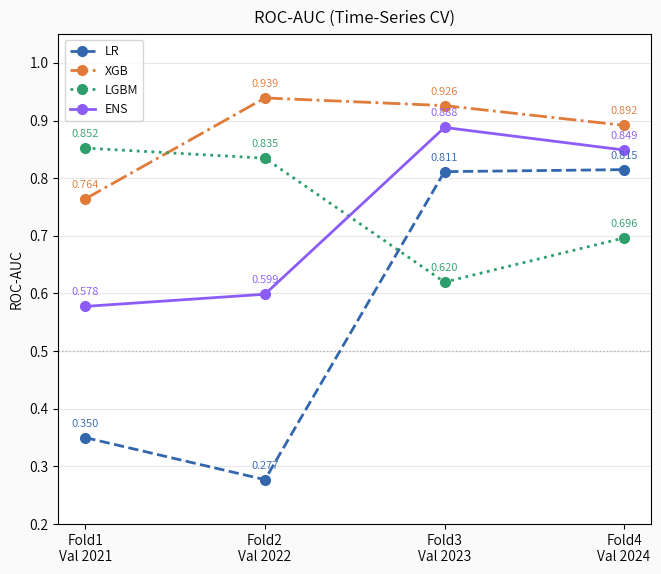

In [10]:
# 9. 可视化
plt.rcParams['axes.unicode_minus'] = False

COLORS = {
    'LR':   '#3266AD',
    'XGB':  '#E07B39',
    'LGBM': '#2E9E6B',
    'ENS':  '#8B5CF6',
    'fin':  '#73726C',
    'nlp':  '#3266AD',
}
fold_labels = [f"Fold{i+1}\nVal {r['验证年份']}" for i, r in enumerate(records)]

fig = plt.figure(figsize=(26, 14))
fig.patch.set_facecolor('#FAFAFA')

# Chart 1: ROC-AUC
ax1 = fig.add_subplot(2, 3, 1)
for key, ls in [('LR','--'), ('XGB','-.'), ('LGBM',':'), ('ENS','-')]:
    vals = res_df[f'{key}_ROC'].tolist()
    ax1.plot(fold_labels, vals, color=COLORS[key], linestyle=ls,
             marker='o', markersize=7, linewidth=2, label=key)
    for i, v in enumerate(vals):
        ax1.annotate(f'{v:.3f}', (i, v), xytext=(0, 8),
                     textcoords='offset points', ha='center',
                     fontsize=8, color=COLORS[key])
ax1.set_ylim(0.2, 1.05)
ax1.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_title('ROC-AUC (Time-Series CV)', fontsize=12, fontweight='bold', pad=8)
ax1.set_ylabel('ROC-AUC', fontsize=10)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(axis='y', alpha=0.3)
ax1.set_facecolor('white')

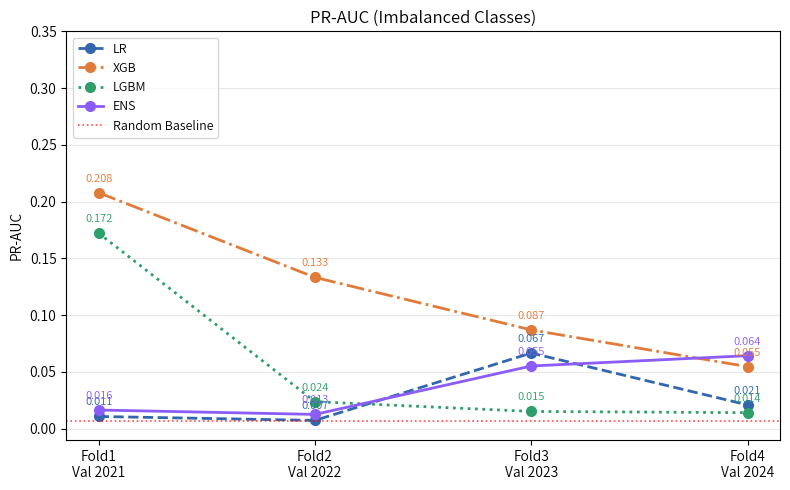

In [11]:
# Chart2：PR-AUC
fig, ax = plt.subplots(figsize=(8, 5))
for key, ls in [('LR','--'), ('XGB','-.'), ('LGBM',':'), ('ENS','-')]:
    vals = res_df[f'{key}_PR'].tolist()
    ax.plot(fold_labels, vals, color=COLORS[key], linestyle=ls,
            marker='o', markersize=7, linewidth=2, label=key)
    for i, v in enumerate(vals):
        ax.annotate(f'{v:.3f}', (i, v), xytext=(0, 8),
                    textcoords='offset points', ha='center',
                    fontsize=8, color=COLORS[key])
ax.axhline(0.007, color='red', linestyle=':', linewidth=1.2, alpha=0.7, label='Random Baseline')
ax.set_ylim(-0.01, 0.35)
ax.set_title('PR-AUC (Imbalanced Classes)', fontsize=12, fontweight='bold')
ax.set_ylabel('PR-AUC', fontsize=10)
ax.legend(fontsize=9, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('white')
plt.tight_layout()
plt.show()

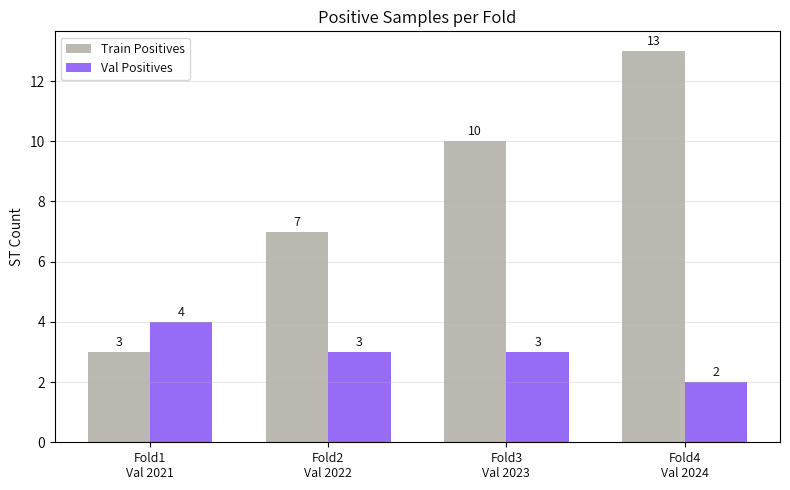

In [12]:
# Chart3: positive sample distribution
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(records))
bw = 0.35
b1 = ax.bar(x - bw/2, res_df['训练正'], bw, label='Train Positives', color='#B4B2A9', alpha=0.9)
b2 = ax.bar(x + bw/2, res_df['验证正'], bw, label='Val Positives', color='#8B5CF6', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(fold_labels, fontsize=9)
ax.set_title('Positive Samples per Fold', fontsize=12, fontweight='bold')
ax.set_ylabel('ST Count', fontsize=10)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('white')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()